# Lecture 1 — Gymnasium, MDPs, and Tabular Q-Learning

**Reinforcement Learning, 2025-26**

## Where we are

In the introductory part of the course you studied **tabular reinforcement learning** from a theoretical standpoint: Markov Decision Processes (MDPs), Bellman equations, dynamic programming, and the family of model-free methods (Q-learning, SARSA, Monte Carlo). You know *why* these methods work and *what* they converge to.

This is the first lecture of the second part of the course, where we shift the focus from *theory* to *practice*, and — starting from Lecture 3 — from *tabular* methods to *function approximation* methods, both linear and deep.

## What you will learn today

By the end of this lecture you will be able to:

1. Describe an informal control problem as a formal **MDP**, identifying its components.
2. Translate an MDP specification into executable code using the **Gymnasium** library, both by using built-in environments and by implementing your own.
3. Implement a **tabular Q-learning agent** from scratch, train it on a custom environment, and analyze its learned policy.

## How we will get there

We do not start from the API. We start from a **problem**: a small biological scenario, just rich enough to expose the design decisions that solving it with RL entails. We will model it formally as an MDP, and only then will we introduce Gymnasium — as the natural answer to the question *"how do I implement this MDP, and how do agents talk to it?"*

This notebook alternates explanatory text, code that illustrates concepts, and references to the `rlc` package shipped with the course, where reusable classes live. All code is meant to be read, executed, and questioned, not memorized.

## The problem: a microbe in a hostile habitat

Imagine a single-celled organism — a **microbe** — living in a thin layer of fluid over a flat surface, which we discretize as a rectangular grid of cells. The microbe occupies one cell at a time and, at regular time intervals, can attempt to move to one of the four neighbouring cells (up, right, down, left).

The habitat is not uniform. There is a **safe region** where the microbe begins its life, and somewhere else in the habitat there is a **nutrient source** that the microbe needs to reach. Between the two lies a **toxic gradient**: a band of cells contaminated by a harmful substance. If the microbe enters a toxic cell, the contact severely damages it; we model this as the microbe being instantly transported back to the safe region, paying a high metabolic cost in the process.

Every movement consumes energy, regardless of the destination. The microbe's "goal", in some sense to be made precise, is to reach the nutrient source while spending as little energy as possible and avoiding toxic cells.

A natural layout is the following: a $4 \times 12$ grid, with the safe region in the bottom-left corner, the nutrient source in the bottom-right corner, and a row of toxic cells separating them along the bottom edge. Two qualitatively different strategies are immediately visible to a human observer: a **short-but-risky path** that hugs the toxic band, and a **long-but-safe path** that detours through the upper rows of the habitat. Which one is "better" depends on what we precisely mean by *better*, and on whether the microbe's movements are perfectly controlled or perturbed by random fluctuations of the surrounding fluid (Brownian motion).

We will refine this scenario into a precise mathematical object — and then into code — over the next sections. For now, two observations are worth keeping in mind:

- The problem is **sequential**: a single move is meaningless in isolation; what matters is the *trajectory* the microbe takes from safe region to nutrient source.
- The problem involves a **trade-off**: longer paths cost more energy but reduce the risk of toxic exposure. There is no single "correct" answer independent of how we weigh these costs.

These two features — **sequentiality and trade-off under uncertainty** — are precisely **what reinforcement learning is designed to address**.

## The MDP

Let $H$ and $W$ denote the grid height and width. Cells are indexed by row $r \in \{0, \dots, H-1\}$ (top to bottom) and column $c \in \{0, \dots, W-1\}$ (left to right), and identified by a single integer $s = r \cdot W + c$.

**State space.** The state is the cell currently occupied by the microbe:

$$\mathcal{S} = \{0, 1, \dots, HW - 1\}.$$

We partition $\mathcal{S}$ into three disjoint subsets: the toxic cells $\mathcal{S}_{\text{toxic}}$, the goal $\{s_{\text{goal}}\}$, and the remaining free cells $\mathcal{S}_{\text{free}} = \mathcal{S} \setminus (\mathcal{S}_{\text{toxic}} \cup \{s_{\text{goal}}\})$. The starting cell $s_{\text{start}} \in \mathcal{S}_{\text{free}}$ is fixed.

**Action space.** Four discrete actions corresponding to the cardinal directions:

$$\mathcal{A} = \{0, 1, 2, 3\} = \{\uparrow, \to, \downarrow, \leftarrow\}.$$

Each action $a$ is associated with a displacement $\Delta(a)$ in row–column coordinates: $\Delta(\uparrow) = (-1, 0)$, $\Delta(\to) = (0, +1)$, $\Delta(\downarrow) = (+1, 0)$, $\Delta(\leftarrow) = (0, -1)$.

**Intended landing cell.** Given a state $s$ at position $(r, c)$ and an action $a'$, the *intended landing cell* $L(s, a')$ is the cell at $(r, c) + \Delta(a')$ clipped to the grid boundaries; if the displacement would cross a boundary, the microbe stays in the same cell.

**Stochastic dynamics.** A parameter $p \in [0, 1]$ controls Brownian-like perturbations. For each commanded action $a$, the *effective* action $\tilde{a}$ actually executed is sampled as

$$\Pr(\tilde{a} = a' \mid a) = \begin{cases} 1 - p & \text{if } a' = a, \\ p / 2 & \text{if } a' \perp a, \\ 0 & \text{otherwise,} \end{cases}$$

where $a' \perp a$ means $a'$ is one of the two actions perpendicular to $a$ (e.g., the perpendiculars of $\uparrow$ are $\to$ and $\leftarrow$). The deterministic case corresponds to $p = 0$.

**Step dynamics.** Given current state $s$ and commanded action $a$, a single step proceeds as follows: (i) sample the effective action $\tilde{a}$ from the slippery distribution; (ii) compute the intended landing cell $L = L(s, \tilde{a})$; (iii) emit next state $s'$, reward $r$, and termination flag according to the table below.

| Condition on $L$                   | Next state $s'$    | Reward $r$ | Terminal? |
|------------------------------------|--------------------|------------|-----------|
| $L = s_{\text{goal}}$              | $s_{\text{goal}}$  | $-1$       | yes       |
| $L \in \mathcal{S}_{\text{toxic}}$ | $s_{\text{start}}$ | $-100$     | no        |
| otherwise                          | $L$                | $-1$       | no        |

In particular, toxic cells trigger a teleport to the start cell but **do not terminate the episode**, while reaching the goal does.

**Initial state distribution.** Deterministic at the start cell:

$$\rho_0(s) = \mathbb{1}[s = s_{\text{start}}].$$

**Discount factor.** The task is undiscounted episodic: $\gamma = 1$.

**Default configuration.** Throughout the rest of the lecture we use $H = 4$, $W = 12$, $s_{\text{start}}$ at row $3$, column $0$, $s_{\text{goal}}$ at row $3$, column $11$, and $\mathcal{S}_{\text{toxic}} = \{(3, c) : 1 \le c \le 10\}$ — a single row of toxic cells along the bottom edge between start and goal. This configuration matches the canonical *Cliff Walking* problem (Sutton & Barto, *Reinforcement Learning: An Introduction*, §6.5), with the biological narrative substituted.

## A library for RL environments: Gymnasium

The MDP we just defined is a mathematical object. To run an agent on it we need an implementation: code that holds the current state, accepts an action, samples the next state, and emits the reward. We could write this from scratch, but doing so for every new problem would mean reinventing a small ad-hoc protocol each time and rebuilding the same plumbing — episode bookkeeping, time limits, seeding, logging — over and over. We would also lose the ability to reuse agents and benchmarks written by others.

[Gymnasium](https://gymnasium.farama.org/) is the *de facto* standard for this. It is an open-source Python library, maintained by the [Farama Foundation](https://farama.org/), that defines a uniform API for single-agent RL environments and ships a large collection of ready-made ones. It is the actively maintained successor of OpenAI's `gym`, which is no longer developed; the API and most environments are nearly identical, but with cleaner semantics for episode termination, seeding, and several other design points we will encounter as we go.

### What Gymnasium provides

**A standardized environment interface.** The central abstraction is the `Env` class, exposing two main methods — `reset(seed=...)` to start a new episode and `step(action)` to advance one time step — plus an `observation_space`, an `action_space`, and a `render()` method. Any code obeying this interface can be plugged into any agent written against it. We dissect this interface in the next sections.

**A space module.** The `gymnasium.spaces` package defines the data types used to describe observations and actions: `Discrete`, `Box`, `Tuple`, `Dict`, `MultiDiscrete`, `MultiBinary`. These are not just type hints: they implement sampling, containment checks, and serialization, and are essential ingredients of any environment definition.

**Wrappers.** The `gymnasium.wrappers` module provides composable transformations of environments — enforcing time limits (`TimeLimit`), recording episode statistics (`RecordEpisodeStatistics`), normalizing observations or rewards, stacking frames, recording videos (`RecordVideo`), and many more. Wrappers preserve the `Env` interface and can be chained.

**A registry.** Environments are identified by string IDs (e.g. `"CartPole-v1"`) and instantiated through `gymnasium.make(...)`. Custom environments can be registered with the same mechanism so that they look indistinguishable from the built-in ones.

**Vectorized environments.** The `gymnasium.vector` module lets you run multiple copies of an environment in parallel, which becomes important for sample-hungry algorithms in the deep RL part of the course.

### Built-in environment families

Gymnasium ships several families of reference environments, organized by domain and complexity. Five are particularly relevant for an RL course:

- **Classic Control** (`CartPole`, `MountainCar`, `MountainCarContinuous`, `Acrobot`, `Pendulum`): low-dimensional continuous-state problems based on simple physics. CartPole is the classical "hello world" of RL; MountainCar will serve as our primary testbed for value function approximation in Lecture 3.
- **Toy Text** (`Blackjack`, `Taxi`, `CliffWalking`, `FrozenLake`): small, fully discrete environments meant for debugging and pedagogy. CliffWalking is the canonical problem our `MicrobeGridEnv` is modelled after; FrozenLake is a stochastic grid with slippery dynamics that we will use briefly today.
- **Box2D** (`LunarLander`, `BipedalWalker`, `CarRacing`): 2D physics simulations using the Box2D engine, with continuous state and either discrete or continuous actions.
- **MuJoCo** (`Ant`, `HalfCheetah`, `Hopper`, `Humanoid`, `Walker2D`, ...): 3D physics-based continuous-control tasks driven by the MuJoCo simulator. These are the standard benchmarks in continuous-control deep RL research.
- **Atari**: a large suite of Atari 2600 games simulated through the [**Arcade Learning Environment**](https://ale.farama.org/index.html) (ALE) emulator. Atari environments are special among Gymnasium families: they involve a full-fledged emulator running ROM images, the observation is an RGB image of the game screen (typically $210 \times 160 \times 3$), the action is a joystick input, and standard preprocessing — frame skipping, grayscale conversion, downscaling, frame stacking — is applied through dedicated wrappers. They are the canonical benchmark for value-based deep RL methods such as DQN, which we will discuss in Lecture 5.

Each family is an optional install extra:

```
pip install "gymnasium[classic-control]"
pip install "gymnasium[toy-text]"
pip install "gymnasium[box2d]"
pip install "gymnasium[mujoco]"
pip install "gymnasium[atari]"
pip install "gymnasium[all]"
```

For this lecture we only need `classic-control` and `toy-text`.

## How an MDP maps to a Gymnasium environment

We are now ready to read the Gymnasium API as a direct implementation of the MDP formalism. The mapping is concise but worth pinning down explicitly, because some elements correspond one-to-one, some live elsewhere, and one is conspicuously absent.

| MDP element | Gymnasium representation |
|---|---|
| State space $\mathcal{S}$ | `env.observation_space`, an instance of a `Space` (e.g. `Discrete`, `Box`) |
| Action space $\mathcal{A}$ | `env.action_space`, an instance of a `Space` |
| Initial state distribution $\rho_0$ | encoded inside `env.reset(seed=...)`, which returns the initial observation |
| Transition kernel $P(s' \mid s, a)$ | encoded operationally inside `env.step(a)`; only sampled, not queryable |
| Reward function $R(s, a, s')$ | returned by `env.step(a)` as the immediate reward $r$ |
| Episode termination ($s$ terminal) | `terminated` flag returned by `env.step(a)` |
| Discount factor $\gamma$ | **not part of the environment** — owned by the agent |

Three observations are essential.

**Gymnasium environments are model-free interfaces.** The transition kernel $P$ and reward function $R$ are not exposed as functions an agent could query: an agent can only *sample* from them by calling `step`. This is a deliberate design choice. It forces algorithms to be expressible as sequences of interactions rather than as analytic computations on $P$ and $R$, and so makes the same code work across environments where $P$ is anything from a tiny lookup table to an Atari emulator. Algorithms that *do* exploit knowledge of $P$ and $R$ — like dynamic programming — sit simply outside Gymnasium's intended scope.

**Observation versus state.** Gymnasium calls the output of `reset` and `step` an *observation*, not a *state*. The two coincide whenever the environment is *fully observable* — that is, the observation contains all information needed to make optimal decisions. Our `MicrobeGridEnv` falls in this category: the cell index uniquely identifies the situation. In partially observable problems (image-based games where the agent cannot see off-screen, dialogue agents, robotics with limited sensors) the observation is a strictly less informative function of the underlying state, and the formalism becomes a *Partially Observable MDP* (POMDP). Gymnasium's API accommodates both cases without distinction.

**The discount factor lives in the agent.** $\gamma$ controls how the agent trades off immediate against future rewards; it is part of the *learning objective*, not of the environment. The same `MicrobeGridEnv` instance can be used by an agent running with $\gamma = 0.9$ and another with $\gamma = 1$, and this is by design: the environment defines *the world*, the agent defines *what it tries to optimize in that world*.

A fourth, more subtle correspondence concerns episode termination. The standard MDP definition has a single notion: a state is either terminal or not. Gymnasium's `step` returns *two* boolean flags, `terminated` and `truncated`. The first corresponds exactly to MDP terminal states. The second has no analogue in the formalism: it signals that the episode was cut short by an external mechanism (typically a maximum-step limit) even though the underlying MDP would have continued. This distinction matters when computing returns and bootstrapping value estimates, and we will return to it in detail when we dissect the `step` API.

In [1]:
import gymnasium as gym

# Instantiate the environment from Gymnasium's registry
env = gym.make("CliffWalking-v1")

# What did we actually get back?
print(f"Returned object:        {env}")
print(f"Underlying env class:   {type(env.unwrapped).__name__}")
print(f"Spec ID:                {env.spec.id}")
print(f"Max episode steps:      {env.spec.max_episode_steps}")
print(f"Available render modes: {env.metadata.get('render_modes')}")

Returned object:        <OrderEnforcing<PassiveEnvChecker<CliffWalkingEnv<CliffWalking-v1>>>>
Underlying env class:   CliffWalkingEnv
Spec ID:                CliffWalking-v1
Max episode steps:      None
Available render modes: ['human', 'rgb_array', 'ansi']


### What `gym.make` actually returns

The output of the cell above reveals two things that are worth dwelling on, because they recur with every Gymnasium environment we will create.

**The returned object is not a bare environment.** Looking at the `Returned object` line, we see something like `<OrderEnforcing<PassiveEnvChecker<CliffWalkingEnv<CliffWalking-v1>>>>`. Each angle bracket level corresponds to a *wrapper* applied automatically by `gym.make`: `PassiveEnvChecker` validates that the environment honours the API at runtime, `OrderEnforcing` ensures `reset` is called before `step`. If the registered environment declares a `max_episode_steps`, an additional `TimeLimit` wrapper is layered on top to enforce truncation. We will study wrappers as a first-class topic in a later section; for now, it is enough to know that `gym.make` returns a *stack* of wrappers, not the raw `Env`.

**`env.unwrapped` exposes the underlying environment.** When we need to reach attributes specific to the environment class itself — and not to its wrappers — we use `env.unwrapped`. In our printout this returns the `CliffWalkingEnv` instance, a `gymnasium.Env` subclass implemented in the `gymnasium.envs.toy_text.cliffwalking` module. As a rule, *agents* should always interact with the wrapped `env` (so that all wrappers take effect), while *introspection or env-specific access* may go through `env.unwrapped`.

The third line of output, `Spec ID: CliffWalking-v1`, confirms which entry in Gymnasium's registry we picked up. The version suffix is meaningful: it is part of the contract. Authors of new environment versions are expected to bump the version number whenever they introduce backward-incompatible changes (different reward function, different observation encoding, different default arguments), so that experimental results remain reproducible. `CliffWalking-v0` and `CliffWalking-v1` are, in practice, two different MDPs.

The fourth line, `Max episode steps: None`, tells us that this environment does not enforce a time limit by default. Episodes terminate only when the agent reaches the goal — a property of CliffWalking that is not shared by most other environments (CartPole, for example, has `Max episode steps: 500`). In the absence of a time limit, a poorly behaving agent may produce arbitrarily long episodes; we will keep this in mind when we set up the random rollout below.

The fifth line lists the `render_modes` declared in the environment's metadata. Gymnasium environments choose which mode to use at instantiation time via the `render_mode` argument of `gym.make`; we did not specify one, which means rendering is disabled for now. We will revisit rendering once we have a learned policy worth visualizing.

In [2]:
# Observation space — the formal state space S of the MDP
print(f"Observation space:        {env.observation_space}")
print(f"  type:                   {type(env.observation_space).__name__}")
print(f"  size:                   {env.observation_space.n}")
print(f"  sample observation:     {env.observation_space.sample()}")

print()

# Action space — the formal action space A of the MDP
print(f"Action space:             {env.action_space}")
print(f"  type:                   {type(env.action_space).__name__}")
print(f"  size:                   {env.action_space.n}")
print(f"  sample action:          {env.action_space.sample()}")

Observation space:        Discrete(48)
  type:                   Discrete
  size:                   48
  sample observation:     34

Action space:             Discrete(4)
  type:                   Discrete
  size:                   4
  sample action:          1


### `reset`: starting an episode

An episode begins with a call to `env.reset()`. This single call performs three things at once: it samples an initial state from $\rho_0$, returns the corresponding observation, and returns an auxiliary `info` dictionary that environments may use to expose extra information not part of the observation itself (debugging data, transition probabilities, raw internal state, and so on).

The signature is `obs, info = env.reset(seed=None, options=None)`. Two arguments deserve attention.

**`seed`**: an integer that *seeds* the environment's internal random number generator. Passing the same seed at the start of training guarantees that every stochastic decision the environment makes — initial state sampling, slippery transitions, anything else — is reproducible across runs. Crucially, `seed` is intended to be passed *only on the first reset of an experiment*, not at every episode: subsequent calls to `reset()` advance the same seeded RNG, producing a deterministic *sequence* of episodes. Re-seeding at every episode would make all episodes start from the same state, which is almost never what you want. Reproducibility for an experiment is achieved by seeding once at the beginning, plus seeding NumPy and any other source of randomness on the agent side.

**`options`**: a dictionary of environment-specific overrides for a single reset (for example, forcing a particular initial state in environments that support it). Most environments ignore it; we will not use it in this lecture.

The return value is a tuple `(obs, info)`. This two-element form is a deliberate change from legacy `gym`, where `reset` returned only the observation: separating the observation from the info dictionary makes the API uniform with `step`, which also returns an `info` field, and makes it explicit when an environment exposes extra channels of information.

In [3]:
# First reset of the experiment: seed the environment's RNG once.
obs, info = env.reset(seed=42)

print(f"Initial observation: {obs}")
print(f"Info dict:           {info}")
print(f"Observation type:    {type(obs).__name__}")
print(f"Is in observation_space? {env.observation_space.contains(obs)}")

Initial observation: 36
Info dict:           {'prob': 1}
Observation type:    int
Is in observation_space? True


The output deserves a careful read.

**`Initial observation: 36`**. Decoding via $s = r \cdot W + c$ with $W = 12$, this is row $3$, column $0$: the bottom-left cell of the grid. This is *exactly* the start state $s_{\text{start}}$ of our formal MDP — a small but reassuring confirmation that Gymnasium's CliffWalking and our paper specification are talking about the same object.

**`Info dict: {'prob': 1.0}`**. CliffWalking exposes through `info` the transition probability of the realized step. Since we are in the deterministic version (`is_slippery=False` by default), the probability is $1.0$. In the slippery version it would be smaller — useful, for instance, to debug exploration or to implement importance-sampling-based methods that need access to the behaviour probability. The `info` dictionary is environment-specific and is *not* part of the MDP: agents that wish to remain general should not depend on its contents.

**`Observation type: int`** and **`Is in observation_space? True`**. The observation is a plain Python integer, and `env.observation_space.contains(obs)` confirms it lies in the declared space. The `contains` method is a useful runtime sanity check, especially when wiring up a custom environment and you want to assert that what you are emitting matches what you said you would emit.

Two consequences worth keeping in mind for the rest of the lecture: the environment is now in a well-defined state, and any subsequent call to `step` will use the seeded RNG to evolve from this state.

### `step`: advancing the environment

A single time step of interaction is performed by passing an action to `env.step`. The signature is `obs, reward, terminated, truncated, info = env.step(action)`. The action must be a valid element of `env.action_space`; for CliffWalking it is therefore an integer in $\{0, 1, 2, 3\}$. The five-tuple returned encodes everything the agent observes about the consequences of its action.

**`obs`**: the next observation $s_{t+1}$, an element of `observation_space` — the result of sampling from the transition kernel $P(\cdot \mid s_t, a_t)$.

**`reward`**: the scalar immediate reward $r_{t+1}$.

**`terminated`** and **`truncated`** are two boolean flags that together signal the end of an episode. They are not interchangeable, and confusing them is a recurrent source of subtle bugs.

`terminated` is `True` when the agent has reached a *terminal state of the MDP*. Termination is part of the environment's specification: in CliffWalking, terminating means having entered the goal cell. In the formalism, terminal states absorb all future reward, which is equivalent to saying that the *true* value of any successor is zero. An agent computing a TD target after a terminated transition must therefore *not* bootstrap, because there is nothing to bootstrap from: the correct target is just the immediate reward.

`truncated` is `True` when the episode was ended *externally*, typically by a `TimeLimit` wrapper enforcing a maximum number of steps, while the underlying MDP would still have continued. This concept does not exist in the standard MDP definition: it is a practical safeguard introduced by the API to prevent infinite episodes. In a truncated transition, the successor state is *not* terminal in the MDP sense — only inaccessible to us — and an agent computing a TD target *should* bootstrap from it, exactly as if the episode were continuing.

The two flags are therefore mutually exclusive in their bootstrapping consequences but not necessarily in their occurrence: nothing prevents an episode from being both terminated and truncated at the same step (e.g. reaching the goal exactly at the step limit). When implementing learning updates, the rule of thumb is: *the bootstrap factor is zero only if `terminated` is True*; `truncated` alone does not zero it.

**`info`**: as for `reset`, an environment-specific dictionary of auxiliary information.

In legacy `gym`, `step` returned a single boolean `done` flag conflating the two cases. The split into `terminated` and `truncated` is one of the most consequential API changes from `gym` to `gymnasium`, and we will rely on it consistently throughout the course.

In [4]:
# We are at the start state (observation 36 from the reset above).
# Try moving "right" (action 1) — towards the cliff edge.
action = 1
obs, reward, terminated, truncated, info = env.step(action)

print(f"Action taken:    {action}  (right)")
print(f"Next observation: {obs}")
print(f"Reward:          {reward}")
print(f"Terminated:      {terminated}")
print(f"Truncated:       {truncated}")
print(f"Info:            {info}")

Action taken:    1  (right)
Next observation: 36
Reward:          -100
Terminated:      False
Truncated:       False
Info:            {'prob': 1.0}


### A random episode

In [5]:
import numpy as np

MAX_STEPS = 200

# Fresh start
obs, info = env.reset(seed=0)
trajectory = [(None, obs, 0.0, False, False)]  # (action, next_obs, reward, terminated, truncated)
total_reward = 0.0

for t in range(MAX_STEPS):
    action = env.action_space.sample()
    next_obs, reward, terminated, truncated, info = env.step(action)
    trajectory.append((action, next_obs, reward, terminated, truncated))
    total_reward += reward
    if terminated or truncated:
        break

print(f"Episode length:    {len(trajectory) - 1} steps")
print(f"Total reward:      {total_reward}")
print(f"Terminated:        {terminated}")
print(f"Truncated:         {truncated}")
print(f"Final observation: {next_obs}  (row={next_obs // 12}, col={next_obs % 12})")
print()
print("First 10 transitions (action, next_obs, reward, terminated, truncated):")
for step in trajectory[1:11]:
    print(f"  {step}")

Episode length:    200 steps
Total reward:      -596.0
Terminated:        False
Truncated:         False
Final observation: 36  (row=3, col=0)

First 10 transitions (action, next_obs, reward, terminated, truncated):
  (np.int64(3), 36, -1, False, False)
  (np.int64(0), 24, -1, False, False)
  (np.int64(0), 12, -1, False, False)
  (np.int64(3), 12, -1, False, False)
  (np.int64(0), 0, -1, False, False)
  (np.int64(1), 1, -1, False, False)
  (np.int64(2), 13, -1, False, False)
  (np.int64(2), 25, -1, False, False)
  (np.int64(1), 26, -1, False, False)
  (np.int64(3), 25, -1, False, False)


### Rendering an episode

Numbers are evocative once you know how to read them, but a visual rendering is more immediate. Gymnasium environments declare their available rendering modes through the `metadata['render_modes']` field we inspected at the very beginning. CliffWalking exposes three: `'human'` opens a pygame window with a graphical view, `'rgb_array'` returns each frame as a NumPy array of pixels suitable for matplotlib or video recording, and `'ansi'` returns a textual rendering of the grid, ideal for inline display in a notebook with no graphical dependencies.

The rendering mode is fixed at instantiation time via the `render_mode` argument of `gym.make` — it cannot be changed on an existing environment. We therefore re-create the env with `render_mode='ansi'` and re-run a short random episode, printing the grid after every step.

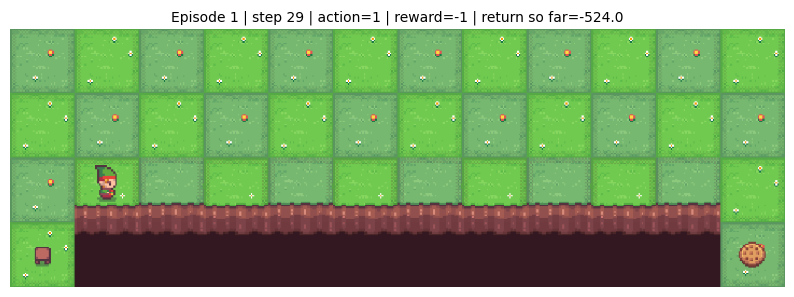

In [6]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# Re-instantiate with the rgb_array render mode
env_anim = gym.make("CliffWalking-v1", render_mode="rgb_array")

def show_frame(frame, title):
    plt.figure(figsize=(10, 4))
    plt.imshow(frame)
    plt.axis("off")
    plt.title(title, fontsize=10)
    plt.show()

TOTAL_FRAMES = 30
FRAME_DELAY = 0.3   # seconds between frames

episode = 1
ep_step = 0
ep_return = 0.0

obs, info = env_anim.reset(seed=0)
show_frame(env_anim.render(),
           title=f"Episode {episode} | step 0 | start (obs={obs})")
time.sleep(FRAME_DELAY)

for _ in range(TOTAL_FRAMES - 1):
    action = env_anim.action_space.sample()
    obs, reward, terminated, truncated, info = env_anim.step(action)
    ep_step += 1
    ep_return += reward

    clear_output(wait=True)
    show_frame(
        env_anim.render(),
        title=(f"Episode {episode} | step {ep_step} | action={action} | "
               f"reward={reward} | return so far={ep_return}")
    )
    time.sleep(FRAME_DELAY)

    if terminated or truncated:
        # Pause briefly, then start a new episode (without re-seeding —
        # we want the seeded RNG sequence to keep advancing).
        time.sleep(FRAME_DELAY * 2)
        episode += 1
        ep_step = 0
        ep_return = 0.0
        obs, info = env_anim.reset()
        clear_output(wait=True)
        show_frame(env_anim.render(),
                   title=f"Episode {episode} | step 0 | start (obs={obs})")
        time.sleep(FRAME_DELAY)

env_anim.close()

## The custom Environment for the microbe scenario

A few design choices in `MicrobeGridEnv` are worth pointing out at a glance; the code itself is meant to be read in class, but the macro-level decisions are summarised here.

The action convention `0=up, 1=right, 2=down, 3=left` matches `CliffWalking-v1`, which lets us use the two environments interchangeably for sanity checks. Displacement and perpendicularity tables live as module-level constants, so the slippery transition is a one-line lookup rather than a chain of `if/elif`.

The transition kernel is implemented in three layers: `_sample_effective_action` resolves the slippery distribution (returning the actually executed action), `_intended_landing` applies the corresponding displacement with boundary clipping, and `step` handles the case-based outcome — goal reaches terminate, toxic cells teleport back to the start with a heavy penalty, anything else is an ordinary move. This decomposition mirrors the *step dynamics* table we wrote when defining the MDP. The seeded `self.np_random` is used everywhere randomness is involved, never `numpy.random` directly: this is the only thing that makes experiments truly reproducible.

The `info` dictionary returned by `step` includes the effective action that was actually executed. For `slippery > 0` this is the only way an external observer can tell when the environment perturbed an action, and it will be useful when we want to verify visually that slippery dynamics are doing what we expect.

The episode bookkeeping keeps a running `_episode_return`, reset to zero on every `reset`. We use it not for control purposes — agents are free to ignore it — but to drive a piece of the renderer.

Rendering uses only `rgb_array`. The grid is drawn at fixed cell pixel size, with a faint background, a purple band for toxic cells, a green nutrient cell, and a faint marker on the start. The microbe itself is drawn as a filled disc whose color interpolates from a vivid green ("healthy", at the start of the episode) to a dark red ("depleted") as the cumulative episode cost grows. With the default reward scheme — every step costs $-1$ and a toxic contact costs $-100$ — the microbe noticeably darkens after each toxic detour and gradually loses vitality on long random walks. This visual cue, free since the rewards are accumulated anyway, will be especially informative once we let an agent loose on the environment: it lets us *see* not just where the microbe is but how well it is doing.

In [7]:
from rlc.envs.microbe import MicrobeGridEnv

env = MicrobeGridEnv(render_mode="rgb_array")

print(f"Observation space: {env.observation_space}")
print(f"Action space:      {env.action_space}")
print(f"Render modes:      {env.metadata['render_modes']}")

obs, info = env.reset(seed=42)
print(f"Initial observation: {obs}  (row={obs // env.width}, col={obs % env.width})")

Observation space: Discrete(48)
Action space:      Discrete(4)
Render modes:      ['rgb_array']
Initial observation: 36  (row=3, col=0)


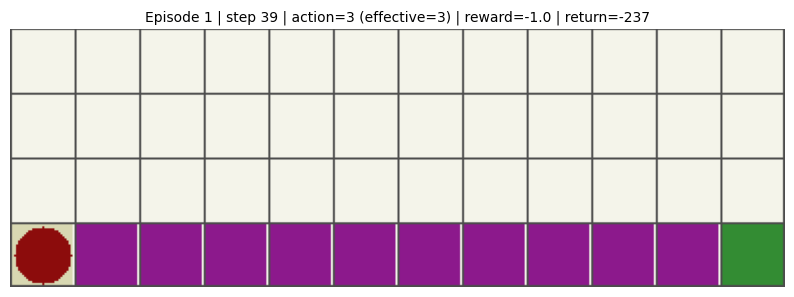

In [8]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

def show_frame(frame, title):
    plt.figure(figsize=(10, 4))
    plt.imshow(frame)
    plt.axis("off")
    plt.title(title, fontsize=10)
    plt.show()

TOTAL_FRAMES = 40
FRAME_DELAY = 0.25

episode = 1
ep_step = 0

obs, info = env.reset(seed=0)
show_frame(env.render(),
           title=f"Episode {episode} | step 0 | start (obs={obs})")
time.sleep(FRAME_DELAY)

for _ in range(TOTAL_FRAMES - 1):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    ep_step += 1

    clear_output(wait=True)
    show_frame(
        env.render(),
        title=(f"Episode {episode} | step {ep_step} | action={action} "
               f"(effective={info['effective_action']}) | "
               f"reward={reward} | return={env._episode_return:.0f}")
    )
    time.sleep(FRAME_DELAY)

    if terminated or truncated:
        time.sleep(FRAME_DELAY * 2)
        episode += 1
        ep_step = 0
        obs, info = env.reset()
        clear_output(wait=True)
        show_frame(env.render(),
                   title=f"Episode {episode} | step 0 | start (obs={obs})")
        time.sleep(FRAME_DELAY)

env.close()

## A first agent: tabular Q-learning

We have an environment but nothing to act in it. The simplest learning agent we can put in front of `MicrobeGridEnv` is **tabular Q-learning** (Watkins, 1989), which you have already studied theoretically in the introductory part of the course. This section is a short reminder, framed in the way we will translate it to code in a moment.

### What Q-learning learns

Q-learning estimates the **optimal action-value function**

$$q_\star(s, a) = \mathbb{E}\!\left[\, \sum_{k=0}^{\infty} \gamma^k R_{t+k+1} \,\Big|\, S_t = s, A_t = a, \pi_\star \right],$$

the expected discounted return obtained by taking action $a$ in state $s$ and acting optimally thereafter. Knowing $q_\star$ is enough to act optimally, because the greedy policy with respect to $q_\star$ is optimal: $\pi_\star(s) \in \arg\max_a q_\star(s, a)$.

In the tabular setting — finite $\mathcal{S}$ and $\mathcal{A}$ — we represent $q_\star$ as a table $Q \in \mathbb{R}^{|\mathcal{S}| \times |\mathcal{A}|}$, one entry per state-action pair. *Learning* means updating the entries of $Q$ from interaction data so that they converge to $q_\star$.

### The update rule

Q-learning is a **temporal-difference** method: after each transition $(S_t, A_t, R_{t+1}, S_{t+1})$ it pushes the current estimate $Q(S_t, A_t)$ towards a one-step *target* that combines the observed reward with a bootstrapped estimate of future return:

$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left[ \underbrace{R_{t+1} + \gamma \max_{a'} Q(S_{t+1}, a')}_{\text{TD target}} - Q(S_t, A_t) \right].$$

Three features are essential and worth pinning down explicitly.

It is a **sample-based update**: it does not require the transition kernel $P$ or the reward function $R$ — only the realised transition. This is exactly what makes the method compatible with the Gymnasium interface, which only lets us *sample* from the environment.

It is **off-policy**. The action $A_t$ that produced the transition was selected by some *behaviour* policy (typically $\varepsilon$-greedy with respect to the current $Q$), but the target uses $\max_{a'} Q(S_{t+1}, a')$ — the value of the *greedy* action at the next state, regardless of which action the behaviour policy will actually take. The agent is, in effect, evaluating the greedy policy while behaving more exploratorily. This is the technical sense of "off-policy" and it is what distinguishes Q-learning from SARSA, which we will see in Lecture 2.

The **bootstrap term must vanish at terminal states**. If $S_{t+1}$ is terminal in the MDP, the true return from there is zero, and the target collapses to the immediate reward $R_{t+1}$ alone. In code this becomes a multiplication by `(1 - terminated)`, never `(1 - done)`: as we discussed, `truncated` does *not* zero the bootstrap factor.

### Behaviour policy: $\varepsilon$-greedy

At every state $S_t$, the agent picks a random action with probability $\varepsilon$ and the greedy action $\arg\max_a Q(S_t, a)$ otherwise. The parameter $\varepsilon$ controls the *exploration–exploitation* trade-off: high values explore widely but exploit poorly; low values exploit aggressively but may miss better policies. In practice $\varepsilon$ is **annealed** from a high initial value to a small floor as the agent gains experience, a schedule that satisfies the *GLIE* condition (Greedy in the Limit with Infinite Exploration) needed for asymptotic convergence guarantees. We will use a simple exponential decay; a linear schedule is an equally common alternative.

### Convergence in one sentence

Under standard conditions — finite MDP, every state-action pair visited infinitely often, learning rate $\alpha_t$ satisfying the Robbins-Monro conditions $\sum_t \alpha_t = \infty$ and $\sum_t \alpha_t^2 < \infty$, GLIE policy — Q-learning's table converges almost surely to $q_\star$. We will not prove this here; we *will* observe it empirically by training on `MicrobeGridEnv` and watching the learning curves.

### What we need to implement

In the next cells we materialise three things, in three modules of the `rlc` package:

- the agent itself (`rlc/agents/q_learning.py`), holding the Q-table and exposing `select_action` and `update` methods;
- a generic training loop (`rlc/utils/training.py`), agnostic to the algorithm — it will work unchanged for SARSA and Monte Carlo in Lecture 2;
- a small set of plotting utilities (`rlc/utils/plotting.py`) for learning curves and learned policies.

The notebook will only orchestrate: instantiate, train, plot, watch the trained microbe.

A few macro-level decisions in `QLearningAgent` are worth a comment.

The interface is deliberately minimal: `select_action(state)` to act, `update(state, action, reward, next_state, terminated)` to learn from a transition, `end_episode()` to perform per-episode bookkeeping. This same triplet works unchanged for SARSA and for Monte Carlo, with the only difference being what each method does internally — SARSA's `update` will need the next action, Monte Carlo's `update` is a no-op while `end_episode` does the actual learning. Adopting a common interface lets the training loop and the plotting utilities be written once and reused across all three agents in Lecture 2.

The Q-learning update closely mirrors the formula written in the previous cell, with one operational subtlety. The bootstrap factor is zeroed out by checking `terminated`, not a generic `done` flag — exactly the rule we discussed when we dissected the `step` API. A truncated transition would still bootstrap, because the next state remains a perfectly valid MDP state we just chose not to keep visiting.

Action selection uses `_argmax_random_tiebreak` rather than `np.argmax`. The reason is purely practical: `np.argmax` returns the first maximiser, which matters when the Q-table has many equal values — in particular at the very beginning of training, when every entry is still equal to `initial_q`. Without random tie-breaking the agent's first few decisions would be entirely deterministic and biased toward action `0`, which on our environment means the microbe consistently bumping against the top wall. Random tie-breaking dissolves this artifact.

The agent owns its own `numpy.random.Generator`, separate from the environment's RNG. This separation is hygienic: re-seeding the agent does not change the environment's stochasticity and vice versa, which makes individual factors of an experiment independently controllable.

Two helper methods, `greedy_policy` and `state_values`, return derived quantities — the greedy action per state and the state-value $V(s) = \max_a Q(s, a)$. They will be the inputs of the policy and value visualisations in the next subsection. They are deliberately not cached: the Q-table changes throughout training, so it is simpler to recompute them on demand than to keep a synchronised mirror.

Finally, the constructor exposes `initial_q` as a parameter. The default value is zero, which is the textbook choice for episodic tasks with non-positive rewards — and ours has step costs of $-1$ and toxic penalties of $-100$. Setting `initial_q` to a *positive* value implements **optimistic initialisation**, a simple but effective trick that encourages the agent to try every state-action pair at least once before settling, because untried actions look more attractive than tried ones until the table corrects itself. We will not use it for our first run, but it is a knob worth knowing about when tuning exploration.

## Training: the agent–environment loop

We have an environment that exposes the Gymnasium API and an agent that exposes a `select_action` / `update` / `end_episode` interface. To make them learn we need a third piece of code that puts the two in dialogue, following the standard *agent–environment loop* — the same diagram you have seen at the very start of the introductory part of the course, now translated into running code.

### What happens in one episode

A single training episode follows a fixed pattern, repeated until termination or truncation.

The episode begins with `obs, info = env.reset()`. The environment samples an initial state from $\rho_0$ and returns the corresponding observation; the agent has not yet acted. The agent's $\varepsilon$ has whatever value the previous episode left it at — the schedule is per-episode, not per-step.

Inside the episode, at every time step:

- the agent picks an action, `action = agent.select_action(obs)`, using its current behaviour policy ($\varepsilon$-greedy with respect to the current Q-table);
- the environment executes the action, `next_obs, reward, terminated, truncated, info = env.step(action)`, advancing one transition;
- the agent updates its Q-table from the realised transition, `agent.update(obs, action, reward, next_obs, terminated)`. Crucially, only `terminated` is passed — `truncated` does not zero the bootstrap, as we discussed when dissecting the `step` API;
- the loop variable advances, `obs = next_obs`, ready for the next iteration.

The episode ends when `terminated or truncated` becomes true. At that point the agent runs its end-of-episode hook, `agent.end_episode()`, which in Q-learning performs the $\varepsilon$ decay. In Monte Carlo, in Lecture 2, the same hook will be where actual learning happens.

### What we want to record

A useful training loop does not just train: it observes. For every episode we will store the *episode return* (the sum of rewards collected) and the *episode length* (number of steps), plus the value of $\varepsilon$ at the end of the episode for diagnostic purposes. These three quantities form the basis of the **learning curves** we plot at the end of training.

### Training performance vs. evaluation performance

There is a subtlety that deserves to be made explicit, because confusing the two is one of the most common pitfalls in empirical RL.

The episode returns collected *during training* are produced by the $\varepsilon$-greedy behaviour policy, which deliberately takes random actions at rate $\varepsilon$. Even after the agent has converged to the optimal Q-table, those episodes will keep showing returns *worse* than optimal, simply because the agent is still being forced to explore. The training learning curve, therefore, measures something halfway between "what the agent has learned" and "how much the agent is currently exploring".

To measure the *quality of what has been learned* we need a separate signal: the return obtained when the agent acts **greedily**, with $\varepsilon$ effectively set to zero, with no learning updates. This is what an *evaluation rollout* does. We will run a small batch of evaluation episodes every `eval_every` training episodes, and we will use the resulting *evaluation curve* — typically much smoother than the training curve — to track learning progress in a clean way. We will see this distinction in action repeatedly throughout the course; it is especially eloquent in Lecture 2, when SARSA and Q-learning will produce *visibly different* gaps between training return and evaluation return.

Both the training loop and the evaluation rollout are best implemented as small reusable utilities in the `rlc` package, since they are entirely algorithm-agnostic — the very same code will drive Q-learning, SARSA, Monte Carlo, and the function approximation agents we will meet later in the course.

### Training the microbe

We can finally see Q-learning in action. We instantiate a fresh `MicrobeGridEnv` and a fresh `QLearningAgent` with default hyperparameters, train for a few hundred episodes, and evaluate the greedy policy periodically along the way. The `TrainingHistory` returned will be the basis of all the plots and animations of the next subsection.

In [9]:
from rlc.envs.microbe import MicrobeGridEnv
from rlc.agents.q_learning import QLearningAgent
from rlc.utils.training import train

# Two environment instances: one for training, one for evaluation.
train_env = MicrobeGridEnv(render_mode="rgb_array")
eval_env = MicrobeGridEnv(render_mode="rgb_array")

agent = QLearningAgent(
    n_states=train_env.observation_space.n,
    n_actions=train_env.action_space.n,
    alpha=0.1,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.995,
    seed=0,
)

history = train(
    agent,
    train_env,
    n_episodes=500,
    max_steps_per_episode=200,
    eval_every=25,
    eval_episodes=20,
    eval_env=eval_env,
    eval_max_steps=200,
    seed=0,
    progress=True,
)

print(f"Final epsilon:                     {agent.epsilon:.3f}")
print(f"Mean return, last 50 train eps:    {np.mean(history.episode_returns[-50:]):.1f}")
print(f"Final greedy evaluation return:    {history.eval_mean_returns[-1]:.1f} "
      f"(std {history.eval_std_returns[-1]:.1f})")

Training:   0%|          | 0/500 [00:00<?, ?ep/s]

Final epsilon:                     0.082
Mean return, last 50 train eps:    -52.8
Final greedy evaluation return:    -13.0 (std 0.0)


### Visualising what was learned

The `TrainingHistory` records the full per-episode signal of the run, but signals are not insights until we plot them. Three pictures are useful and we will produce them in this order.

The first is the **training learning curve**: episode return vs. episode index, possibly smoothed. This is the noisiest of the three — every dip is a random action that found a toxic cell — but it is the picture that most directly answers "is the agent learning at all?".

The second is the **evaluation curve**: mean greedy return computed every `eval_every` training episodes. By construction it is far smoother than the training curve, and it is the picture that answers "*how well* has the agent learned at this point in training?". The two curves naturally appear on the same plot, and reading them together is half the diagnostic skill of empirical RL.

The third is the **learned policy and value function**: a 2D heatmap of $V(s) = \max_a Q(s, a)$ over the grid, with arrows showing the greedy action in each cell. This is the picture that answers "*what* did the agent learn?". On our 4×12 grid we expect the heatmap to grade smoothly from low values near the start toward zero at the goal, and the arrows to draw a clear path along the row immediately above the toxic band — the textbook *risky shortcut* that Q-learning is famous for finding.

The plotting helpers go into `rlc/utils/plotting.py`. They are written once and reused across all subsequent lectures: SARSA, Monte Carlo, and the function-approximation methods will produce the same kinds of pictures.

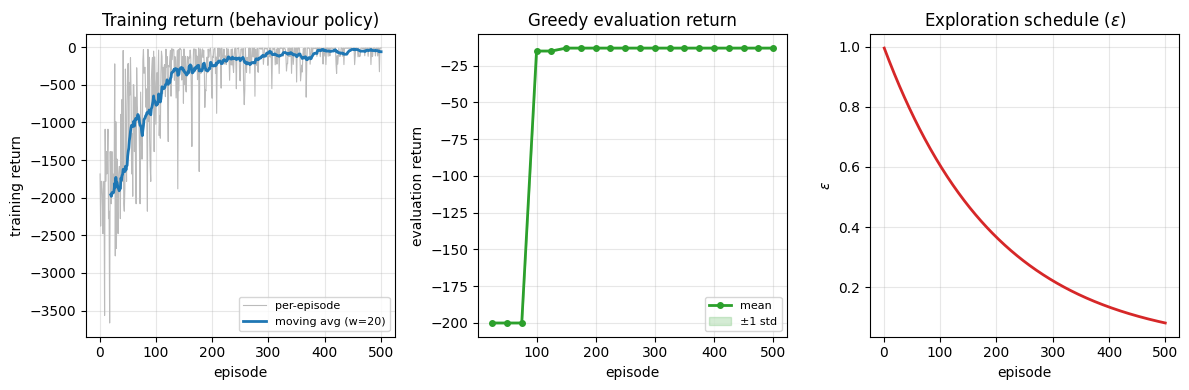

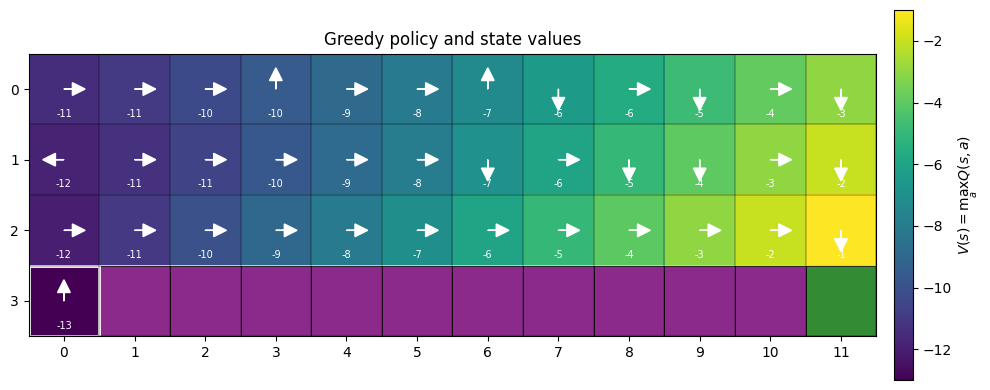

In [10]:
from rlc.utils.plotting import plot_learning_curves, plot_grid_policy_and_values

fig1 = plot_learning_curves(history)
plt.show()

fig2 = plot_grid_policy_and_values(agent, train_env, annotate_values=True)
plt.show()

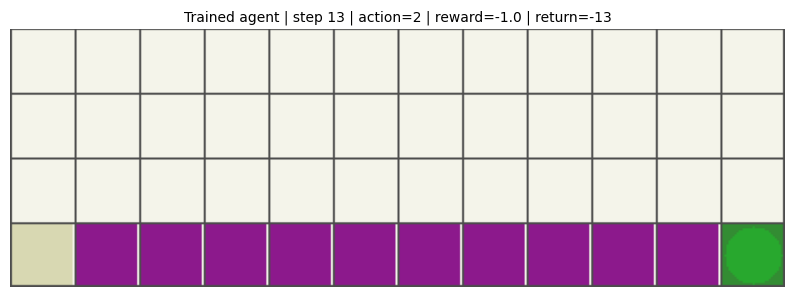

Episode ended after 13 steps with return -13.


In [11]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

def show_frame(frame, title):
    plt.figure(figsize=(10, 4))
    plt.imshow(frame)
    plt.axis("off")
    plt.title(title, fontsize=10)
    plt.show()

FRAME_DELAY = 0.3
MAX_STEPS = 50

# Use the eval_env (already in rgb_array mode) and run a single greedy episode.
obs, info = eval_env.reset(seed=123)
ep_step = 0
ep_return = 0.0

show_frame(eval_env.render(),
           title=f"Trained agent | step 0 | start (obs={obs})")
time.sleep(FRAME_DELAY)

for _ in range(MAX_STEPS):
    action = agent.select_action(obs, greedy=True)
    obs, reward, terminated, truncated, info = eval_env.step(action)
    ep_step += 1
    ep_return += reward

    clear_output(wait=True)
    show_frame(
        eval_env.render(),
        title=(f"Trained agent | step {ep_step} | action={action} | "
               f"reward={reward} | return={ep_return:.0f}")
    )
    time.sleep(FRAME_DELAY)

    if terminated or truncated:
        break

print(f"Episode ended after {ep_step} steps with return {ep_return:.0f}.")